In [12]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [13]:
# --- parameters ---
lam = 3.0    # arrival rate (visits per hour)
T   = 10.0   # observation window (hours)

The exponential distribution has the density function:

f(x) = λ · e^(−λx)

In [14]:
# inter-arrival times are Exponential with mean 1/lam
# if X ~ Exp(lam), then E[X] = 1/lam
inter_arrivals = rng.exponential(scale=1/lam, size=1000)

If the times between events are Exp(λ), then, the count of events in [0,T] is Poisson(λT)

In [ ]:
# cumulative sum turns intervals into positions in time
arrivals = np.cumsum(inter_arrivals)

# keep only arrivals that fall within the observation window
arrivals = arrivals[arrivals <= T]

N = len(arrivals)
print(f"Simulated arrivals : N(T) = {N}")
print(f"Expected  E[N(T)]  = λ·T = {lam * T:.1f}")

Simulated arrivals : N(T) = 32
Expected  E[N(T)]  = λ·T = 30.0


### Layer 1 — Visualization

Top panel: the counting process N(t) — how visits accumulate over time.
Bottom panel: the individual events on the timeline.

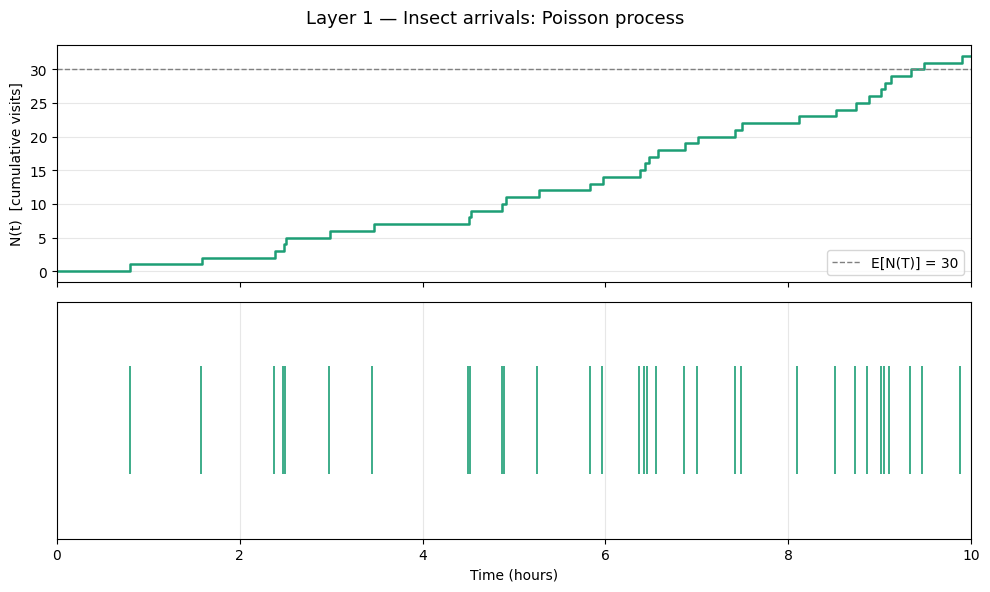

In [ ]:
# --- build the counting process ---
t_grid = np.linspace(0, T, 500) # time points to evaluate N(t)
N_t    = np.searchsorted(arrivals, t_grid, side='right')

# --- plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("Layer 1 — Insect arrivals: Poisson process", fontsize=13)

# counting process
axes[0].step(t_grid, N_t, where='post', color='#1D9E75', linewidth=1.8)
axes[0].axhline(lam * T, color='gray', linestyle='--', linewidth=1,
                label=f"E[N(T)] = {lam * T:.0f}")
axes[0].set_ylabel("N(t)  [cumulative visits]")
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# event timeline
axes[1].eventplot(arrivals, lineoffsets=0, linelengths=0.6,
                  color='#1D9E75', linewidth=1.2)
axes[1].set_yticks([])
axes[1].set_xlabel("Time (hours)")
axes[1].set_xlim(0, T)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()